# Middle mile · encher o caminhão, sair no horário, escolher o caminho

No caso Vértice, o objetivo O2 (expansão nacional) atingiu a pontualidade do line-haul, mas **estourou o contrapeso de custo por kg**. Este notebook abre a caixa do middle mile e ataca as três decisões que formam esse custo:

| # | Decisão | Técnica | KPI |
|---|---|---|---|
| 1 | Como encher o veículo? | Bin packing 2D (heurística FFD × ótimo por programação inteira) · mix de frota | MM-003 |
| 2 | Esperar encher ou sair no horário? | Simulação de eventos discretos (hora a hora, 60 dias) | MM-002, MM-012 |
| 3 | Em que ordem visitar as cidades? | Clarke-Wright + 2-opt · dimensionamento do veículo por rota | MM-004, MM-011, MM-013 |
| 4 | Vale abrir um ponto de transbordo? Onde? | Localização de instalações por enumeração + roteirização por satélite | MM-004, MM-012, LM-011 |

> Caixas **🧠 Por dentro** explicam técnica e código; **🎯 Leitura executiva** traduz em decisão. Especificações de veículos, custos e demanda são premissas (camada D); coordenadas das cidades são aproximadas.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from kpikit import middle_mile as mm
pd.set_option('display.float_format', '{:,.3f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.DataFrame([vars(v) for v in mm.FROTA.values()]).set_index('nome')

,peso_kg,volume_m3,custo_km,custo_fixo_dia
nome,,,,
VUC,3000,18,3.200,350
Toco,6000,35,4.500,450
Truck,12000,50,5.800,550
Carreta,25000,90,7.800,750


## 1. Consolidação · o que enche o caminhão: kg ou m³?

In [2]:
lotes = mm.gerar_lotes(120)
truck = mm.FROTA['Truck']
alocado = mm.consolidar(lotes, truck)
ocup = mm.resumo_ocupacao(alocado, truck)
print(f"{len(lotes)} lotes · {lotes.peso_kg.sum():,.0f} kg · {lotes.volume_m3.sum():,.1f} m³ · densidade média {lotes.peso_kg.sum()/lotes.volume_m3.sum():,.0f} kg/m³")
print(f"Veículos (FFD): {len(ocup)} · limite inferior teórico: {mm.limite_inferior_veiculos(lotes, truck)}")
ocup

120 lotes · 26,226 kg · 169.1 m³ · densidade média 155 kg/m³
Veículos (FFD): 4 · limite inferior teórico: 4


,peso_kg,volume_m3,lotes,ocup_peso,ocup_volume,restricao_ativa,ocupacao
veiculo,,,,,,,
0,"8,546.000",49.620,25,0.712,0.992,volume,0.992
1,"7,778.000",49.790,30,0.648,0.996,volume,0.996
2,"6,775.000",49.600,40,0.565,0.992,volume,0.992
3,"3,127.000",20.040,25,0.261,0.401,volume,0.401


🧠 **Por dentro da técnica · bin packing em 2 dimensões.** Cada lote tem peso **e** volume, e o veículo tem limite nos dois. A heurística **First-Fit Decreasing (FFD)** ordena os lotes do "mais difícil" para o mais fácil (pela dimensão dominante: `max(peso/cap_peso, volume/cap_volume)`) e coloca cada um no primeiro veículo em que cabe. É rápida e costuma ficar a 1 veículo do ótimo.

O **limite inferior** (`ceil(max(Σpeso/cap, Σvolume/cap))`) é a régua: nenhuma solução usa menos veículos que isso. Quando FFD = limite inferior, a solução é comprovadamente ótima.

🎯 **Leitura executiva.** Com carga de e-commerce (~150 kg/m³), **o volume enche o veículo antes do peso**: ocupação de ~85% em m³ contra ~55% em kg. Um painel que mede ocupação só por peso mostra ociosidade que não existe e empurra a decisão errada (consolidar mais em um veículo que já está cheio). Por isso o KPI MM-003 é definido na **restrição ativa**.

In [3]:
pequeno = mm.gerar_lotes(25, semente=5)
vuc = mm.FROTA['VUC']
n_otimo, _ = mm.consolidar_otimo(pequeno, vuc)
print(f"VUC · 25 lotes → limite inferior {mm.limite_inferior_veiculos(pequeno, vuc)} · FFD {mm.consolidar(pequeno, vuc).veiculo.nunique()} · ótimo (MILP) {n_otimo}")

VUC · 25 lotes → limite inferior 2 · FFD 2 · ótimo (MILP) 2


🧠 **Heurística × ótimo.** `consolidar_otimo` resolve o mesmo problema de forma exata, por programação inteira (`scipy.optimize.milp`): variável binária *x[i,b]* = "lote *i* vai no veículo *b*". O custo computacional explode com o tamanho, e é por isso que operações reais usam heurísticas e guardam o exato para validá-las em amostras. A **quebra de simetria** (usar o veículo 2 só se o 1 estiver em uso) corta soluções equivalentes e acelera o solver.

In [4]:
cargas = {'4 t · 26 m³': (4_000, 26), '7 t · 40 m³': (7_000, 40), '20 t · 100 m³': (20_000, 100), '30 t · 170 m³': (30_000, 170)}
pd.concat({k: mm.mix_frota(kg_, m3_, km_ida_volta=240) for k, (kg_, m3_) in cargas.items()}, names=['carga do dia'])

veiculo  quantidade     custo
carga do dia                                  
4 t · 26 m³   0     Toco           1 1,530.000
7 t · 40 m³   0    Truck           1 1,942.000
20 t · 100 m³ 0      VUC           1 1,118.000
              1  Carreta           1 2,622.000
30 t · 170 m³ 0  Carreta           2 5,244.000

🎯 **Mix de frota.** A combinação de menor custo muda com o **perfil da carga**, e nem sempre é "o maior veículo que couber". Para 20 t e 100 m³, o ótimo é **carreta + VUC**, não duas carretas: o excedente de 10 m³ não justifica uma segunda carreta. Com as premissas de custo usadas aqui, a escolha praticamente não muda com a distância. Com custo fixo mais alto ou pedágio por eixo, passaria a mudar, e por isso o modelo recebe a distância. É um problema inteiro pequeno que o planejador deveria rodar por rota, não uma tabela fixa.

## 2. Política de despacho · esperar encher ou sair no horário?

In [5]:
carreta = mm.FROTA['Carreta']
curva = mm.curva_despacho(volume_dia_m3=350, veiculo=carreta, km_ida_volta=240, prazo_h=8)
curva

,politica,parametro,viagens_dia,ocupacao_media,custo_por_m3,pct_volume_no_prazo,espera_media_h
0,encher,0.500,7.017,0.552,45.217,1.000,1.126
1,encher,0.600,6.050,0.639,39.081,1.000,1.415
2,encher,0.700,5.750,0.672,37.143,1.000,1.492
3,encher,0.800,5.267,0.735,33.986,1.000,1.743
4,encher,0.900,5.200,0.745,33.519,1.000,1.817
5,encher,1.000,5.200,0.745,33.519,1.000,1.913
6,encher_sem_trava,0.500,6.517,0.594,42.052,1.000,1.277
7,encher_sem_trava,0.600,5.433,0.711,35.097,1.000,1.626
8,encher_sem_trava,0.700,4.900,0.789,31.652,0.983,1.891
9,encher_sem_trava,0.800,4.367,0.887,28.140,0.974,2.222


Text(0.0, 1.0, 'Fronteira custo × pontualidade · faixa de 350 m³/dia, carreta')

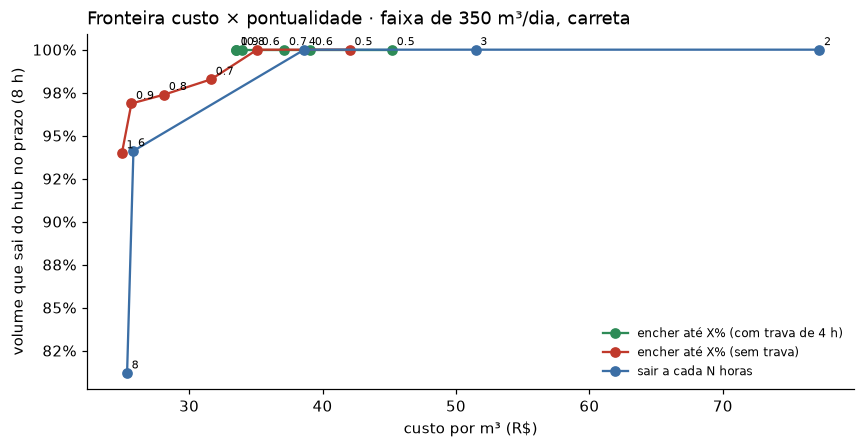

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.2))
cores = {'encher': '#2e8b57', 'encher_sem_trava': '#c0392b', 'horario': '#3b6ea5'}
rotulos = {'encher': 'encher até X% (com trava de 4 h)', 'encher_sem_trava': 'encher até X% (sem trava)', 'horario': 'sair a cada N horas'}
for pol, g in curva.sort_values('custo_por_m3').groupby('politica'):
    ax.plot(g.custo_por_m3, g.pct_volume_no_prazo, marker='o', color=cores[pol], label=rotulos[pol])
    for _, r in g.iterrows():
        ax.annotate(f"{r.parametro:g}", (r.custo_por_m3, r.pct_volume_no_prazo), fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('custo por m³ (R$)'); ax.set_ylabel('volume que sai do hub no prazo (8 h)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}')); ax.legend(frameon=False, fontsize=8)
ax.set_title('Fronteira custo × pontualidade · faixa de 350 m³/dia, carreta', loc='left')

🧠 **Por dentro da técnica · simulação de eventos discretos.** O hub recebe volume hora a hora (Poisson, com o perfil do dia: pico no fim da tarde). A cada hora, a política decide se o veículo sai. O embarque é **FIFO**: o volume mais antigo embarca primeiro, e cada m³ carrega a hora em que chegou. Isso permite medir exatamente quanto saiu dentro do prazo. Rodamos 60 dias para a média não depender de um dia atípico. É a técnica certa quando não existe fórmula fechada e o que importa é a interação entre **aleatoriedade** e **regra de decisão**.

🎯 **Leitura executiva**
- **Sair em horário fixo curto** (a cada 2–4 h) garante o prazo, mas roda com o veículo meio vazio: é a política cara.
- **Esperar encher sem trava** é a mais barata, mas **perde prazo** justamente nas horas de pouco volume (madrugada). É a política que um gestor pressionado por custo adota sem perceber o efeito no cliente.
- **A regra híbrida** ("sai quando atingir 80% **ou** quando o volume mais antigo esperar metade do prazo") fica na fronteira: **100% no prazo** com custo por m³ **~12% menor** que sair a cada 4 h (R$ 34 × R$ 38,6). Para descer abaixo disso, até ~R$ 25/m³, é preciso **aceitar 3–6% do volume fora do prazo**. É uma decisão explícita de nível de serviço, que deve estar **escrita no procedimento** e não ser decidida no turno. É exatamente o trade-off ocupação × pontualidade (MM-003 × MM-002) de `00-fundamentos/interdependencias.md`.

## 3. Roteirização · milk run a partir do hub de Recife

In [7]:
C = mm.CIDADES_NE
D = mm.matriz_distancias(C)
kg = C.demanda_kg.to_numpy(float); m3 = kg / mm.DENSIDADE_ECOMMERCE_KG_M3
nomes = C.cidade.tolist()
print(f"{len(C)-1} cidades · {kg.sum():,.0f} kg/dia · {m3.sum():,.0f} m³/dia · Recife→Natal ≈ {D[0, nomes.index('Natal')]:.0f} km · Recife→Sousa ≈ {D[0, nomes.index('Sousa')]:.0f} km")

20 cidades · 53,300 kg/dia · 355 m³/dia · Recife→Natal ≈ 317 km · Recife→Sousa ≈ 495 km


🧠 **Por dentro da técnica · Clarke-Wright (1964).** Comece com uma rota exclusiva por cidade (hub → cidade → hub). Unir as rotas de *i* e *j* economiza

$$s(i,j) = d(0,i) + d(0,j) - d(i,j)$$

porque o veículo deixa de voltar ao hub entre *i* e *j*. O algoritmo ordena todas as economias e une rotas da maior para a menor, **se** a carga couber (peso e volume) e a rota não passar da extensão máxima. Depois, o **2-opt** tenta inverter trechos de cada rota para desfazer cruzamentos.

A distância usa **haversine** (distância sobre a esfera) × 1,25 de sinuosidade. Em produção, use a matriz real de um motor de rotas (OSRM, Google, HERE).

In [8]:
resultados = {km: mm.comparar_cenarios(km_max=km) for km in (500, 700, 900, 1_100, np.inf)}
resultados[900]

,rotas,km,custo,ocupacao_media,maior_rota_h,pernoites,custo_por_kg
direto,22.000,"11,482.201","88,696.766",0.323,19.682,10.000,1.664
milk run,12.000,"8,061.135","61,354.582",0.592,19.682,8.000,1.151
milk run + right-sizing,12.000,"8,061.135","49,786.016",0.745,19.682,8.000,0.934


,veiculo,sequencia,km,kg,m3,ocupacao,horas,pernoites,custo
0,Truck,Caruaru → Vitória de Santo Antão,309.432,"7,000.000",46.667,0.933,6.966,0,"2,344.703"
1,Truck,Campina Grande → Caicó → Patos,820.358,"6,900.000",46.000,0.920,16.926,1,"6,308.079"
2,Toco,Mossoró,"1,045.671","2,900.000",19.333,0.552,19.682,1,"6,055.519"
3,Truck,Maceió,508.527,"7,200.000",48.000,0.960,9.916,0,"3,499.457"
4,VUC,Serra Talhada,941.563,"1,100.000",7.333,0.407,17.789,1,"4,163.002"
5,Truck,Palmares → Penedo → Arapiraca → Garanhuns,840.751,"6,500.000",43.333,0.867,17.966,1,"6,426.354"
6,Toco,Goiana → Guarabira → Arcoverde → Santa Cruz do...,817.375,"4,800.000",32.000,0.914,18.211,1,"5,028.187"
7,VUC,Sousa,990.651,900.000,6.000,0.333,18.682,1,"4,320.084"
8,Toco,João Pessoa,258.587,"3,900.000",26.000,0.743,5.372,0,"1,613.641"
9,Toco,João Pessoa,258.587,"3,900.000",26.000,0.743,5.372,0,"1,613.641"


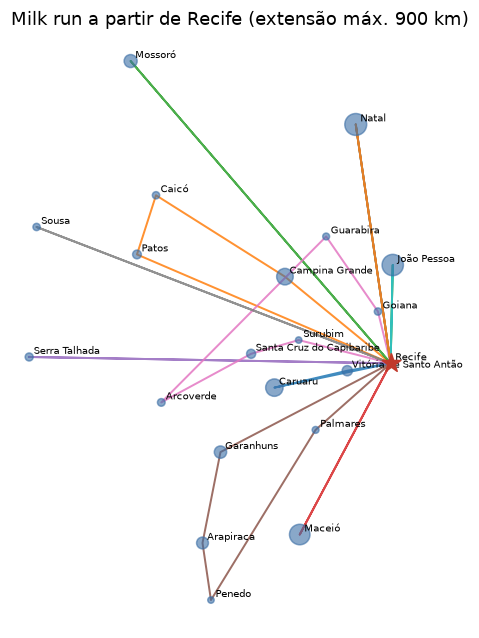

In [9]:
v = mm.FROTA['Truck']
rotas = [mm.dois_opt(r, D) for r in mm.clarke_wright(kg, m3, D, v, km_max=900)]
detalhe = mm.avaliar_rotas(rotas, kg, m3, D, v, nomes, frota=mm.FROTA)
fig, ax = plt.subplots(figsize=(7.5, 7))
ax.scatter(C.lon[1:], C.lat[1:], s=kg[1:] / 40, color='#3b6ea5', alpha=.6, zorder=3)
ax.scatter(C.lon[0], C.lat[0], s=160, marker='*', color='#c0392b', zorder=4)
for r, cor in zip(rotas, plt.cm.tab10.colors * 3):
    cam = [0, *r, 0]
    ax.plot(C.lon[cam], C.lat[cam], color=cor, lw=1.3, alpha=.85)
for _, c in C.iterrows():
    ax.annotate(c.cidade.replace(' (hub)', ''), (c.lon, c.lat), fontsize=6.5, xytext=(3, 2), textcoords='offset points')
ax.set_title('Milk run a partir de Recife (extensão máx. 900 km)', loc='left'); ax.set_aspect('equal'); ax.axis('off')
detalhe[['veiculo', 'sequencia', 'km', 'kg', 'm3', 'ocupacao', 'horas', 'pernoites', 'custo']]

In [10]:
pd.DataFrame({('∞' if not np.isfinite(k) else f'{k:,.0f} km'): r.loc['milk run + right-sizing', ['rotas', 'km', 'custo', 'ocupacao_media', 'maior_rota_h', 'pernoites']]
              for k, r in resultados.items()}).T

,rotas,km,custo,ocupacao_media,maior_rota_h,pernoites
500 km,17.000,"10,430.261","55,916.523",0.670,19.682,10.000
700 km,15.000,"9,633.041","55,671.586",0.635,19.682,10.000
900 km,12.000,"8,061.135","49,786.016",0.745,19.682,8.000
"1,100 km",10.000,"6,504.272","46,799.754",0.832,22.521,7.000
∞,10.000,"5,758.895","40,481.025",0.845,30.881,5.000


🎯 **Leitura executiva**
- **Direto × milk run × veículo certo.** Com extensão máxima de 900 km, o milk run corta ~30% do custo diário em relação a "um caminhão por cidade", e **escolher o veículo certo para cada rota** corta mais ~20%. As duas alavancas se somam, e a segunda não exige nenhum algoritmo, só disciplina de planejamento.
- **A rota mais barata não é a melhor.** Sem limite de extensão, o custo cai ainda mais, mas a maior rota passa de **30 h**: a última cidade recebe no **segundo dia**, e a promessa D+1 do O2 quebra. **A extensão máxima da rota é uma decisão de serviço**, que tem que vir da promessa ao cliente, não do planejador de transporte.
- **Jornada é restrição, não detalhe.** Rotas acima de ~11 h exigem pernoite ou segundo motorista (o modelo cobra isso). ⚠️ As regras de jornada (Lei 13.103/2015 e convenções) devem ser validadas com o jurídico.
- **Cidades do sertão (Sousa, Patos, Mossoró, Serra Talhada)** geram as rotas longas. A alternativa estrutural é um **ponto de transbordo**: carreta cheia até ele e veículos menores na capilaridade. A seção 4 testa onde isso se paga.
- **Governança do contrapeso do O2:** custo/kg deve ser acompanhado **por região e com mix constante** (medida DAX `Custo por kg Mix Constante`). O ganho de roteirização aparece como queda real, e não se confunde com o efeito mix.


## 4. Rede com transbordo · vale abrir um satélite? Onde?

🧠 **Por dentro da técnica · localização de instalações.** Um **satélite de transbordo** (cross-dock) recebe carretas cheias do hub e redistribui com veículos menores. Ele troca **km de caminhão meio vazio** por **custo fixo + manuseio + tempo de transbordo**. Para cada combinação de satélites candidatos (até 2 dos 4, isto é, 11 redes), o modelo:
1. atribui cada cidade à instalação mais próxima (hub ou satélite aberto);
2. calcula o line-haul hub → satélite em carretas (1 viagem ida e volta = meio dia de veículo);
3. roteiriza cada satélite com Clarke-Wright + 2-opt e veículo dimensionado por rota;
4. mede o **serviço**: hora de chegada em cada cidade desde a saída do hub, contra a janela de entrega (14 h).

Com poucos candidatos, a **enumeração completa** é a escolha certa: garante o ótimo dentro das premissas e é auditável. Com dezenas de candidatos, o problema vira um MILP de localização (*capacitated facility location*).

**Detalhe que muda o resultado:** o sentido em que uma rota é percorrida não muda o km, mas muda **quem recebe primeiro**. `_orientar` escolhe o sentido que entrega mais kg dentro da janela.

In [11]:
redes = mm.comparar_redes()
redes[['satelites', 'custo_dia', 'custo_transbordo_total', 'km', 'pernoites', 'pct_demanda_no_prazo', 'ultima_entrega_h', 'cidades_fora_do_prazo']]

,satelites,custo_dia,custo_transbordo_total,km,pernoites,pct_demanda_no_prazo,ultima_entrega_h,cidades_fora_do_prazo
0,Patos,"44,056.483","8,820.581","6,173.552",4,0.981,16.073,Arcoverde
1,(sem transbordo),"49,786.016",0.000,"8,061.135",8,0.987,15.294,Surubim
2,Caruaru + Patos,"50,315.115","17,924.677","6,904.064",3,0.983,15.877,Sousa
3,Campina Grande + Patos,"50,514.781","18,592.986","6,618.941",3,0.981,16.073,Arcoverde
4,Campina Grande,"53,673.315","13,260.608","7,619.400",6,1.000,13.607,
5,Campina Grande + Caruaru,"54,560.958","18,616.502","7,571.226",5,1.000,13.607,
6,Caruaru,"57,237.930","12,216.144","8,756.831",8,1.000,13.335,
7,Arcoverde + Patos,"58,043.927","22,301.155","7,824.089",4,1.000,13.973,
8,Campina Grande + Arcoverde,"60,047.187","23,208.980","8,195.828",4,0.979,15.077,Serra Talhada
9,Arcoverde,"61,133.557","18,904.861","8,938.738",6,0.946,15.702,Mossoró


Text(0.0, 1.0, 'Custo × serviço das configurações de rede (verde = mais barata que sem transbordo)')

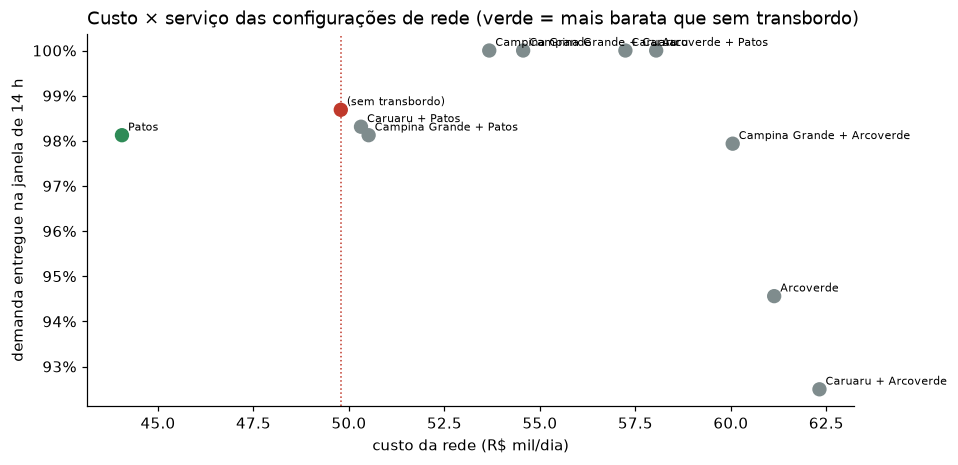

In [12]:
base = redes.set_index('satelites').loc['(sem transbordo)', 'custo_dia']
fig, ax = plt.subplots(figsize=(9, 4.4))
cor = ['#c0392b' if s == '(sem transbordo)' else '#2e8b57' if c < base else '#7f8c8d' for s, c in zip(redes.satelites, redes.custo_dia)]
ax.scatter(redes.custo_dia / 1e3, redes.pct_demanda_no_prazo, s=70, c=cor)
for _, r in redes.iterrows():
    ax.annotate(r.satelites, (r.custo_dia / 1e3, r.pct_demanda_no_prazo), fontsize=7, xytext=(4, 3), textcoords='offset points')
ax.axvline(base / 1e3, color='#c0392b', ls=':', lw=1)
ax.set_xlabel('custo da rede (R$ mil/dia)'); ax.set_ylabel('demanda entregue na janela de 14 h')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title('Custo × serviço das configurações de rede (verde = mais barata que sem transbordo)', loc='left')

🎯 **Transbordo só se paga longe do hub.** O satélite em **Patos**, no sertão, é a única configuração **mais barata** que a rede atual (−11,5%, com pernoites caindo de 8 para 4): a carreta cheia substitui várias viagens longas de caminhão meio vazio. Satélites em **Caruaru** ou **Campina Grande**, a ~150–180 km de Recife, **encarecem** a rede (+8% a +15%): a distância economizada não paga custo fixo, manuseio e a viagem extra da carreta. Eles até melhoram o prazo, mas a um custo que outra alavanca resolve mais barato (a seguir).

In [13]:
from dataclasses import replace
cen = {f'{h} h antes': mm.avaliar_rede(['Patos'], p=mm.ParametrosRede(antecipacao_linehaul_h=h)) for h in (0, 2, 3)}
pd.DataFrame({k: {'custo_dia': v['custo_dia'], 'pct_no_prazo': v['pct_demanda_no_prazo'], 'ultima_entrega_h': v['ultima_entrega_h'],
                  'fora_do_prazo': v['cidades_fora_do_prazo'] or '—'} for k, v in cen.items()}).T

,custo_dia,pct_no_prazo,ultima_entrega_h,fora_do_prazo
0 h antes,"44,056.483",0.981,16.073,Arcoverde
2 h antes,"44,056.483",0.981,14.073,Arcoverde
3 h antes,"44,056.483",1.000,13.073,—


🎯 **A onda antecipada fecha o gap de serviço sem custo.** Com o satélite em Patos, Arcoverde fica fora da janela. Fazer a carreta do satélite sair **3 h antes** da onda geral do hub (primeira onda de separação dedicada ao satélite) leva o atendimento a **100% no prazo** com o **mesmo custo**. É uma decisão de **sequenciamento de ondas no CD**, não de transporte: o middle mile se resolve dentro do armazém. (Premissa: o CD consegue antecipar a separação desse volume; validar com a capacidade de onda do SC-009.)

In [14]:
sens = pd.DataFrame([{'custo_fixo_satelite_dia': fx,
                      'variacao_vs_rede_atual': mm.avaliar_rede(['Patos'], p=mm.ParametrosRede(custo_fixo_satelite_dia=fx))['custo_dia'] / base - 1}
                     for fx in (2_500, 5_000, 7_500, 8_000, 8_500, 10_000)])
sens

,custo_fixo_satelite_dia,variacao_vs_rede_atual
0,2500,-0.115
1,5000,-0.065
2,7500,-0.015
3,8000,-0.005
4,8500,0.005
5,10000,0.036


🎯 **Robustez da decisão.** A premissa de custo fixo do satélite é R$ 2.500/dia, mas **a decisão só se inverte acima de ~R$ 8.200/dia**: há margem de mais de 3× para erro de estimativa. É assim que se apresenta uma recomendação de rede a um comitê: **decisão + ponto de virada**, não só o número do cenário base.

**Recomendação para o comitê (caso Vértice):**
1. Abrir **satélite de transbordo em Patos (PB)** para o sertão (Sousa, Caicó, Mossoró, Serra Talhada, Arcoverde).
2. Criar **onda antecipada** no hub para a carreta do satélite (−3 h).
3. Manter capitais e agreste atendidos direto do hub, com **veículo dimensionado por rota**.
4. Acompanhar **custo/kg por região com mix constante** (DAX `Custo por kg Mix Constante`) e **MM-013** (rotas acima da jornada) como contrapeso.

---
*KPIs: MM-003 (ocupação na restrição ativa), MM-004 (custo/kg), MM-011 (paradas por rota), MM-012 (volume despachado no prazo), MM-013 (rotas acima da jornada). Material de portfólio com premissas declaradas.*